# Context-Aware Wine Recommender: Contextual Pre-Filtering with ALS

Here we focus on three timestamp-derived contexts that already exist in the XWines data:

1. time_of_day
2. day_of_week
3. season

In [1]:
import warnings
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

POSITIVE_THRESHOLD = 4.0
MIN_POSITIVE_INTERACTIONS = 5
MAX_POSITIVE_INTERACTIONS = 250
MAX_USERS = 5000
TEST_FRACTION = 0.2

ALS_FACTORS = 64
ALS_REGULARIZATION = 0.05
ALS_ITERATIONS = 15
ALS_ALPHA = 40

RATINGS_SAMPLE_N = None  # set to an integer for a faster classroom demo
CONTEXT_MIN_TRAIN_ROWS = 1_500
CONTEXT_MIN_TEST_ROWS = 250
CONTEXT_MIN_USERS = 75


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'dataset').exists() and (candidate / 'EDA').exists():
            return candidate
    raise FileNotFoundError('Project root with dataset/ and EDA/ not found')


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / 'dataset'
NOTEBOOK_DIR = PROJECT_ROOT / 'context_aware_filtering'
SHARED_SPLIT_DIR = PROJECT_ROOT / 'data' / 'results' / 'shared_split'

print('Project root:', PROJECT_ROOT)
print('Dataset dir :', DATASET_DIR)
print('Shared split:', SHARED_SPLIT_DIR)

Project root: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system
Dataset dir : /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/dataset
Shared split: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/shared_split


In [2]:
wine_cols = ['WineID', 'WineName', 'Type', 'Country', 'RegionName', 'Body', 'Acidity']
rating_cols = ['UserID', 'WineID', 'Rating', 'Date']

wines = pd.read_csv(
    DATASET_DIR / 'XWines_Full_100K_wines.csv',
    usecols=wine_cols,
    dtype={
        'WineID': 'int32',
        'WineName': 'string',
        'Type': 'category',
        'Country': 'category',
        'RegionName': 'string',
        'Body': 'category',
        'Acidity': 'category',
    },
)

rating_dtypes = {
    'UserID': 'int32',
    'WineID': 'int32',
    'Rating': 'float32',
    'Date': 'string',
}

if RATINGS_SAMPLE_N is None:
    ratings = pd.read_csv(
        DATASET_DIR / 'XWines_Full_21M_ratings.csv',
        usecols=rating_cols,
        dtype=rating_dtypes,
    )
    ratings_load_mode = 'full'
else:
    chunks = []
    collected = 0
    chunk_size = 1_000_000
    for chunk in pd.read_csv(
        DATASET_DIR / 'XWines_Full_21M_ratings.csv',
        usecols=rating_cols,
        dtype=rating_dtypes,
        chunksize=chunk_size,
    ):
        need = RATINGS_SAMPLE_N - collected
        if need <= 0:
            break
        take = min(len(chunk), need)
        chunks.append(chunk.iloc[:take].copy())
        collected += take
    ratings = pd.concat(chunks, ignore_index=True)
    ratings_load_mode = f'sampled_first_{RATINGS_SAMPLE_N:,}'

ratings['Date'] = pd.to_datetime(ratings['Date'], errors='coerce')
wines = wines.drop_duplicates(subset='WineID').copy()
ratings = ratings.dropna(subset=['Date']).sort_values('Date')
ratings = ratings.drop_duplicates(subset=['UserID', 'WineID'], keep='last').copy()
ratings = ratings[ratings['WineID'].isin(wines['WineID'])].copy()

print('Wines loaded  :', wines.shape)
print('Ratings loaded:', ratings.shape, '| mode:', ratings_load_mode)
print('Users         :', ratings['UserID'].nunique())
print('Items         :', ratings['WineID'].nunique())
print('Date range    :', ratings['Date'].min(), 'to', ratings['Date'].max())

Wines loaded  : (100646, 7)
Ratings loaded: (20590800, 4) | mode: full
Users         : 1056079
Items         : 100646
Date range    : 2012-01-03 08:20:53 to 2021-12-31 23:59:56


## 1. Derive context from the timestamp

The original ALS notebook ignores time completely. Here we transform the rating timestamp into three explicit contextual variables:

- time_of_day: night, morning, afternoon, evening
- day_of_week: Monday to Sunday
- season: winter, spring, summer, autumn

These contexts were chosen because they are already available from the Date field, so we do not need to invent new features or assume extra user metadata. They also represent three different levels of temporal behavior:

- time_of_day captures short-term routines
- day_of_week captures weekly behavioral patterns
- season captures slower long-term trends

This gives us multidimensional data of the form:

user x wine x rating x context

but we still train standard 2D recommenders by slicing the data into separate context-specific interaction tables.

In [3]:
def map_time_of_day(hour: int) -> str:
    if 0 <= hour < 6:
        return 'night'
    if 6 <= hour < 12:
        return 'morning'
    if 12 <= hour < 18:
        return 'afternoon'
    return 'evening'


month_to_season = {
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn',
}

day_of_week_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]

ratings['hour'] = ratings['Date'].dt.hour
ratings['month'] = ratings['Date'].dt.month
ratings['day_of_week'] = pd.Categorical(
    ratings['Date'].dt.day_name(),
    categories=day_of_week_order,
    ordered=True,
)
ratings['time_of_day'] = ratings['hour'].apply(map_time_of_day)
ratings['season'] = ratings['month'].map(month_to_season)

ratings_with_meta = ratings.merge(
    wines[['WineID', 'Type', 'Country', 'Body', 'Acidity']],
    on='WineID',
    how='left',
)

context_overview = pd.DataFrame({
    'rows': [len(ratings)],
    'users': [ratings['UserID'].nunique()],
    'wines': [ratings['WineID'].nunique()],
    'time_of_day_values': [ratings['time_of_day'].nunique()],
    'day_of_week_values': [ratings['day_of_week'].nunique()],
    'season_values': [ratings['season'].nunique()],
})

time_of_day_counts = ratings['time_of_day'].value_counts().reindex(
    ['night', 'morning', 'afternoon', 'evening']
).fillna(0).astype(int)
day_of_week_counts = ratings['day_of_week'].value_counts().reindex(
    day_of_week_order
).fillna(0).astype(int)
season_counts = ratings['season'].value_counts().reindex(
    ['winter', 'spring', 'summer', 'autumn']
).fillna(0).astype(int)

display(context_overview)
display(time_of_day_counts.rename('time_of_day_count').to_frame())
display(day_of_week_counts.rename('day_of_week_count').to_frame())
display(season_counts.rename('season_count').to_frame())

,rows,users,wines,time_of_day_values,day_of_week_values,season_values
0,20590800,1056079,100646,4,7,4


,time_of_day_count
time_of_day,
night,4855350
morning,2366690
afternoon,5320891
evening,8047869


,day_of_week_count
day_of_week,
Monday,2193675
Tuesday,2086516
Wednesday,2201450
Thursday,2394805
Friday,3178667
Saturday,4430766
Sunday,4104921


,season_count
season,
winter,5407631
spring,5032431
summer,5026833
autumn,5123905


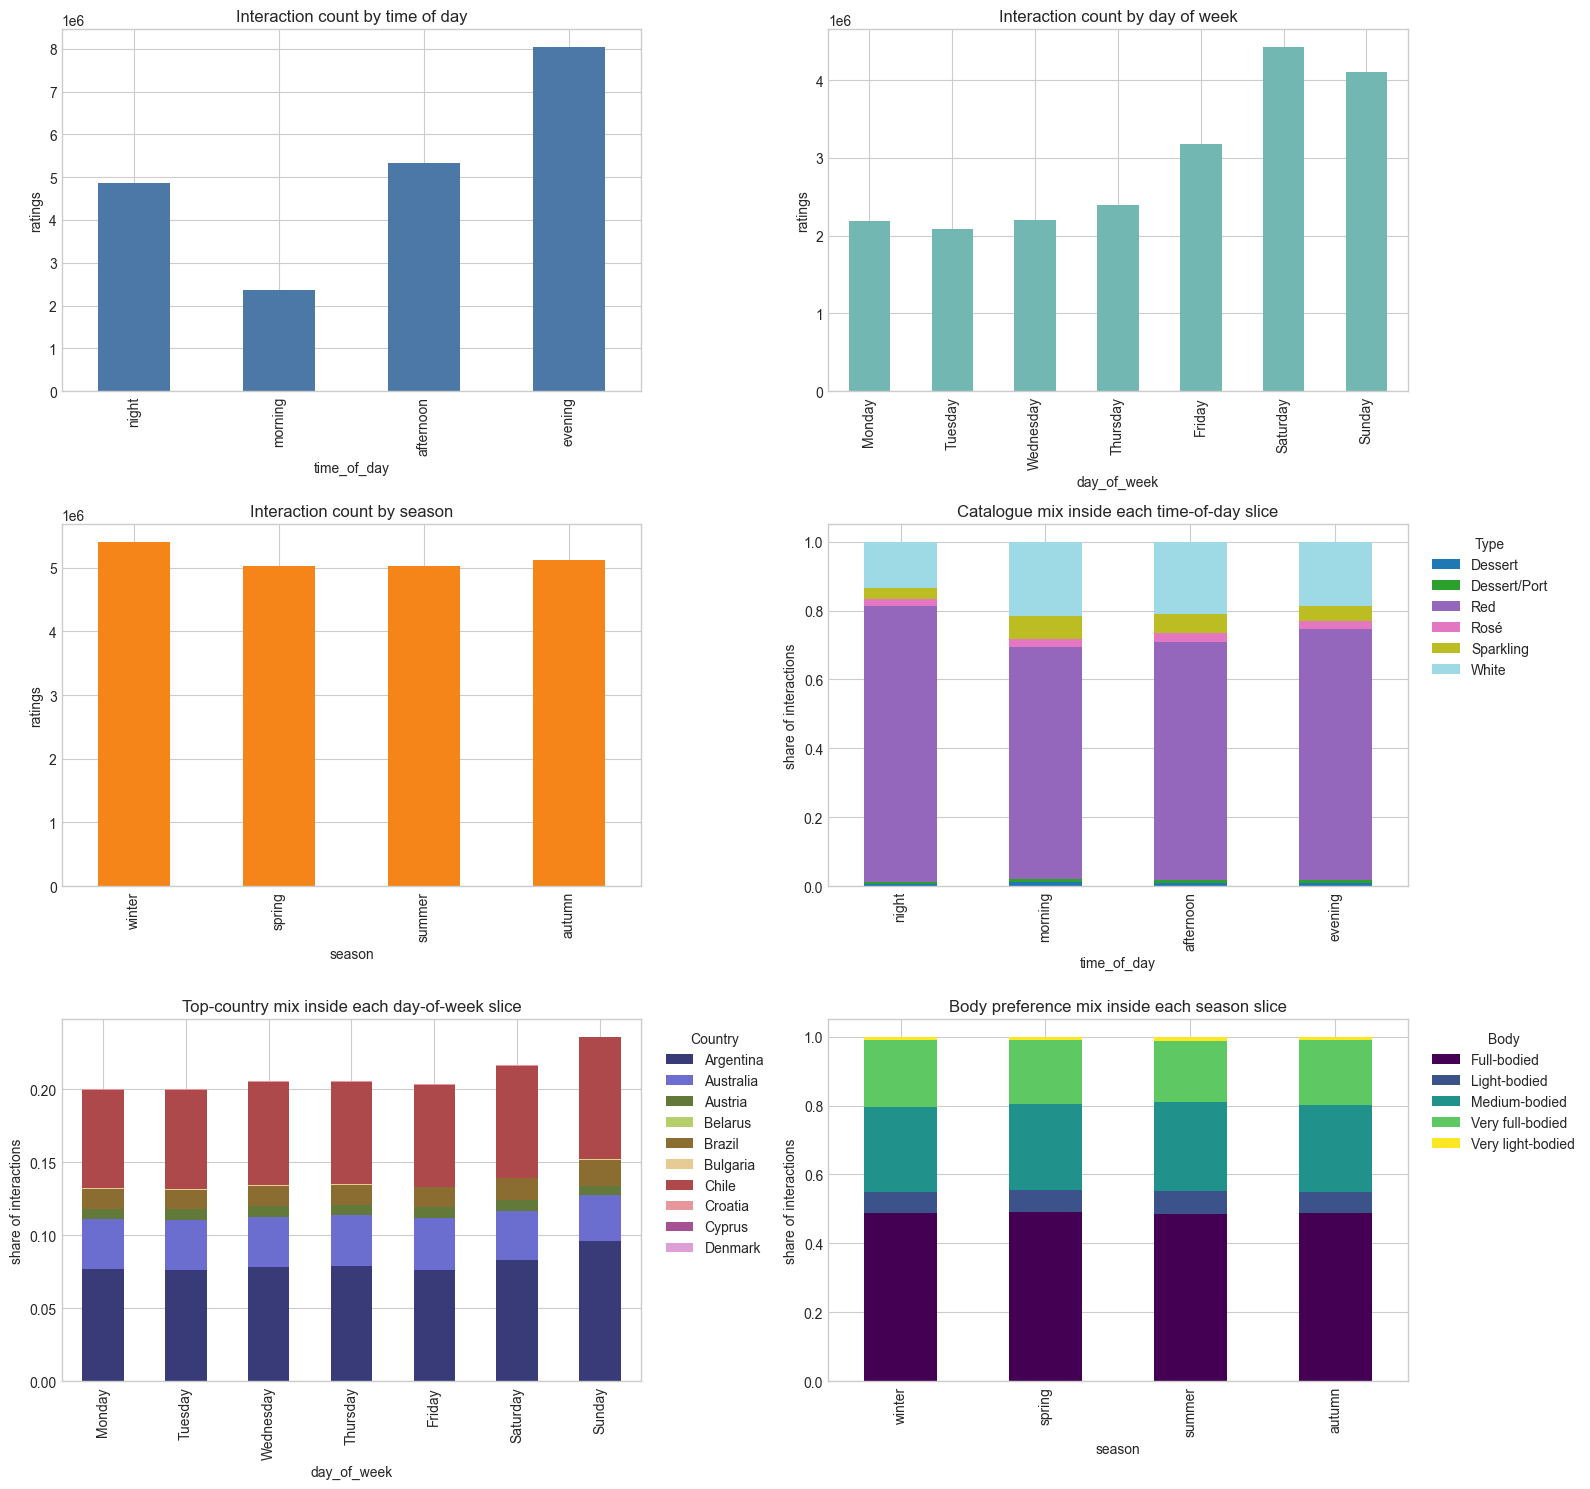

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

ratings['time_of_day'].value_counts().reindex(
    ['night', 'morning', 'afternoon', 'evening']
).plot(kind='bar', ax=axes[0, 0], color='#4C78A8')
axes[0, 0].set_title('Interaction count by time of day')
axes[0, 0].set_xlabel('time_of_day')
axes[0, 0].set_ylabel('ratings')

ratings['day_of_week'].value_counts().reindex(
    day_of_week_order
).plot(kind='bar', ax=axes[0, 1], color='#72B7B2')
axes[0, 1].set_title('Interaction count by day of week')
axes[0, 1].set_xlabel('day_of_week')
axes[0, 1].set_ylabel('ratings')

ratings['season'].value_counts().reindex(
    ['winter', 'spring', 'summer', 'autumn']
).plot(kind='bar', ax=axes[1, 0], color='#F58518')
axes[1, 0].set_title('Interaction count by season')
axes[1, 0].set_xlabel('season')
axes[1, 0].set_ylabel('ratings')

time_type_share = (
    ratings_with_meta.groupby(['time_of_day', 'Type']).size().unstack(fill_value=0)
    .reindex(['night', 'morning', 'afternoon', 'evening'])
)
(time_type_share.div(time_type_share.sum(axis=1), axis=0)).plot(
    kind='bar', stacked=True, ax=axes[1, 1], colormap='tab20'
)
axes[1, 1].set_title('Catalogue mix inside each time-of-day slice')
axes[1, 1].set_xlabel('time_of_day')
axes[1, 1].set_ylabel('share of interactions')
axes[1, 1].legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')

day_country_share = (
    ratings_with_meta.groupby(['day_of_week', 'Country']).size().unstack(fill_value=0)
    .reindex(day_of_week_order)
)
(day_country_share.div(day_country_share.sum(axis=1), axis=0).iloc[:, :10]).plot(
    kind='bar', stacked=True, ax=axes[2, 0], colormap='tab20b'
)
axes[2, 0].set_title('Top-country mix inside each day-of-week slice')
axes[2, 0].set_xlabel('day_of_week')
axes[2, 0].set_ylabel('share of interactions')
axes[2, 0].legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')

season_body_share = (
    ratings_with_meta.groupby(['season', 'Body']).size().unstack(fill_value=0)
    .reindex(['winter', 'spring', 'summer', 'autumn'])
)
(season_body_share.div(season_body_share.sum(axis=1), axis=0)).plot(
    kind='bar', stacked=True, ax=axes[2, 1], colormap='viridis'
)
axes[2, 1].set_title('Body preference mix inside each season slice')
axes[2, 1].set_xlabel('season')
axes[2, 1].set_ylabel('share of interactions')
axes[2, 1].legend(title='Body', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 2. Positive interactions and train/test split

We keep the same collaborative filtering setup as the existing ALS notebook:

- only ratings >= 4.0 count as positive interactions
- users need between 5 and 250 positive interactions
- we evaluate on the shared 5000-user split used across the project

To ensure fair comparison with the other notebooks, we load `train_pos.csv` and `test_pos.csv` from `data/results/shared_split/` instead of building a new random split inside this notebook.


In [5]:
positive = ratings[ratings['Rating'] >= POSITIVE_THRESHOLD].copy()
user_counts = positive['UserID'].value_counts()

eligible_users = user_counts[
    (user_counts >= MIN_POSITIVE_INTERACTIONS) &
    (user_counts <= MAX_POSITIVE_INTERACTIONS)
].index
positive = positive[positive['UserID'].isin(eligible_users)].copy()

train_pos_shared = pd.read_csv(
    SHARED_SPLIT_DIR / 'train_pos.csv',
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)
test_pos_shared = pd.read_csv(
    SHARED_SPLIT_DIR / 'test_pos.csv',
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)

# Add context labels to the shared split rows from the ratings table.
context_cols = ['UserID', 'WineID', 'Date', 'time_of_day', 'day_of_week', 'season']
context_lookup = (
    positive[context_cols]
    .drop_duplicates(subset=['UserID', 'WineID'], keep='last')
)

train_pos = train_pos_shared.merge(context_lookup, on=['UserID', 'WineID'], how='left')
test_pos = test_pos_shared.merge(context_lookup, on=['UserID', 'WineID'], how='left')

missing_train_ctx = train_pos[['time_of_day', 'day_of_week', 'season']].isna().any(axis=1).sum()
missing_test_ctx = test_pos[['time_of_day', 'day_of_week', 'season']].isna().any(axis=1).sum()

if missing_train_ctx or missing_test_ctx:
    print(
        f'Warning: missing context rows after merge -> '
        f'train={missing_train_ctx}, test={missing_test_ctx}'
    )

print('Shared train positives:', train_pos.shape)
print('Shared test positives :', test_pos.shape)
print('Train users           :', train_pos['UserID'].nunique())
print('Test users            :', test_pos['UserID'].nunique())
print('Eligible positives    :', positive.shape)

display(train_pos['time_of_day'].value_counts().rename('train_time_of_day').to_frame())
display(test_pos['time_of_day'].value_counts().rename('test_time_of_day').to_frame())
display(train_pos['day_of_week'].value_counts().reindex(day_of_week_order).rename('train_day_of_week').to_frame())
display(test_pos['day_of_week'].value_counts().reindex(day_of_week_order).rename('test_day_of_week').to_frame())
display(train_pos['season'].value_counts().rename('train_season').to_frame())
display(test_pos['season'].value_counts().rename('test_season').to_frame())

Shared train positives: (56673, 7)
Shared test positives : (16646, 7)
Train users           : 5000
Test users            : 5000
Eligible positives    : (12085645, 9)


,train_time_of_day
time_of_day,
evening,22198
afternoon,14182
night,13684
morning,6522


,test_time_of_day
time_of_day,
evening,6582
afternoon,4127
night,4027
morning,1884


,train_day_of_week
day_of_week,
Monday,5808
Tuesday,5561
Wednesday,5893
Thursday,6521
Friday,8795
Saturday,12616
Sunday,11392


,test_day_of_week
day_of_week,
Monday,1765
Tuesday,1548
Wednesday,1763
Thursday,1883
Friday,2557
Saturday,3777
Sunday,3327


,train_season
season,
winter,14849
autumn,14330
summer,13757
spring,13650


,test_season
season,
winter,4413
autumn,4215
summer,4089
spring,3903


## 3. Metrics, ALS model, and contextual evaluation helpers

The recommender itself is still a standard implicit-feedback ALS model.

What changes is the training data:

- the global baseline sees all positive interactions
- each contextual model only sees the interactions inside one context slice

To make the comparison fair, we evaluate the contextual model and the global baseline on the same context-specific test slice for time_of_day, day_of_week, and season.

In [6]:
def accuracy_at_k(relevant, recommended, k):
    rec_k = recommended[:k]
    if k == 0:
        return 0.0
    hits = sum(1 for item in rec_k if item in relevant)
    return hits / k


def recall_at_k(relevant, recommended, k):
    if not relevant:
        return 0.0
    rec_k = recommended[:k]
    hits = sum(1 for item in rec_k if item in relevant)
    return hits / len(relevant)


def dcg_at_k(relevant, recommended, k):
    score = 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            score += 1.0 / np.log2(rank + 1)
    return score


def ndcg_at_k(relevant, recommended, k):
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg_at_k(relevant, recommended, k) / idcg


item_meta = wines.set_index('WineID')[['Type', 'Country']].copy()
item_meta['Type'] = item_meta['Type'].astype(str).str.lower().fillna('unknown')
item_meta['Country'] = item_meta['Country'].astype(str).str.lower().fillna('unknown')
item_signatures = {
    wine_id: {f"type:{row['Type']}", f"country:{row['Country']}"}
    for wine_id, row in item_meta.iterrows()
}


def jaccard_distance(a, b):
    union = len(a | b)
    return 0.0 if union == 0 else 1.0 - (len(a & b) / union)


def intra_list_diversity(recommended):
    if len(recommended) < 2:
        return 0.0
    distances = []
    for i in range(len(recommended)):
        for j in range(i + 1, len(recommended)):
            distances.append(
                jaccard_distance(
                    item_signatures.get(recommended[i], {'unknown'}),
                    item_signatures.get(recommended[j], {'unknown'}),
                )
            )
    return float(np.mean(distances)) if distances else 0.0


def personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=RANDOM_STATE):
    users = list(recs_by_user.keys())
    if len(users) < 2:
        return 0.0
    rng = np.random.default_rng(random_state)
    if len(users) > max_users:
        users = rng.choice(users, size=max_users, replace=False).tolist()
    top_k_sets = {user_id: set(recs_by_user[user_id][:k]) for user_id in users}
    overlaps = []
    for user_a, user_b in itertools.combinations(users, 2):
        a, b = top_k_sets[user_a], top_k_sets[user_b]
        union = len(a | b)
        overlaps.append((len(a & b) / union) if union > 0 else 0.0)
    return float(1.0 - np.mean(overlaps)) if overlaps else 0.0


def evaluate_model(artifact, recommend_fn, eval_users, relevant_dict, ks=(5, 10, 20)):
    rows = []
    recs_by_user = {}
    all_top10_items = []
    max_k = max(ks)

    for user_id in eval_users:
        relevant = relevant_dict.get(user_id, set())
        if not relevant:
            continue
        recs = recommend_fn(artifact, user_id, top_k=max_k)
        if not recs:
            continue
        recs_by_user[user_id] = recs
        all_top10_items.extend(recs[:10])
        row = {'UserID': user_id}
        for k in ks:
            row[f'Accuracy@{k}'] = accuracy_at_k(relevant, recs, k)
            row[f'Recall@{k}'] = recall_at_k(relevant, recs, k)
            row[f'NDCG@{k}'] = ndcg_at_k(relevant, recs, k)
            row[f'Diversity@{k}'] = intra_list_diversity(recs[:k])
        rows.append(row)

    eval_df = pd.DataFrame(rows)
    if eval_df.empty:
        return eval_df, {}, recs_by_user

    coverage = len(set(all_top10_items)) / len(artifact['all_items']) if len(artifact['all_items']) else 0.0
    pers = personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=RANDOM_STATE)
    return eval_df, {'Coverage': coverage, 'Personalisation@10': pers}, recs_by_user


def summarise_eval(eval_df, extras):
    if eval_df.empty:
        return {}
    summary = eval_df.drop(columns='UserID').mean().to_dict()
    summary.update(extras)
    return summary


def fit_als_model(
    train_df,
    all_wine_ids,
    factors=ALS_FACTORS,
    regularization=ALS_REGULARIZATION,
    iterations=ALS_ITERATIONS,
    alpha=ALS_ALPHA,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)

    users = sorted(train_df['UserID'].unique())
    active_wines = sorted(train_df['WineID'].unique())
    user2idx = {user_id: idx for idx, user_id in enumerate(users)}
    item2idx = {wine_id: idx for idx, wine_id in enumerate(active_wines)}

    u_idx = train_df['UserID'].map(user2idx).values
    i_idx = train_df['WineID'].map(item2idx).values
    ratings_arr = train_df['Rating'].values.astype('float32')

    n_users = len(users)
    n_items = len(active_wines)
    user_item = sp.csr_matrix((ratings_arr, (u_idx, i_idx)), shape=(n_users, n_items))
    item_user = user_item.T.tocsr()

    item_factors = (rng.standard_normal((n_items, factors)) * 0.01).astype('float32')
    user_factors = np.zeros((n_users, factors), dtype='float32')
    reg_eye = (regularization * np.eye(factors)).astype('float32')

    for iteration in range(iterations):
        yty = item_factors.T @ item_factors
        for user_idx in range(n_users):
            start, end = user_item.indptr[user_idx], user_item.indptr[user_idx + 1]
            if start == end:
                continue
            item_indices = user_item.indices[start:end]
            conf = 1.0 + alpha * user_item.data[start:end]
            item_vectors = item_factors[item_indices]
            a_mat = yty + (item_vectors * (conf - 1.0)[:, None]).T @ item_vectors + reg_eye
            b_vec = item_vectors.T @ conf
            user_factors[user_idx] = np.linalg.solve(a_mat, b_vec)

        xtx = user_factors.T @ user_factors
        for item_idx in range(n_items):
            start, end = item_user.indptr[item_idx], item_user.indptr[item_idx + 1]
            if start == end:
                continue
            user_indices = item_user.indices[start:end]
            conf = 1.0 + alpha * item_user.data[start:end]
            user_vectors = user_factors[user_indices]
            a_mat = xtx + (user_vectors * (conf - 1.0)[:, None]).T @ user_vectors + reg_eye
            b_vec = user_vectors.T @ conf
            item_factors[item_idx] = np.linalg.solve(a_mat, b_vec)

        print(f'  Iteration {iteration + 1:2d}/{iterations}')

    return {
        'user_factors': user_factors,
        'item_factors': item_factors,
        'user2idx': user2idx,
        'item2idx': item2idx,
        'idx2item': {idx: wine_id for wine_id, idx in item2idx.items()},
        'all_items': np.array(sorted(all_wine_ids)),
        'train_seen': train_df.groupby('UserID')['WineID'].apply(set).to_dict(),
    }


def recommend_als(artifact, user_id, top_k=10):
    user_idx = artifact['user2idx'].get(user_id)
    if user_idx is None:
        return []

    user_vec = artifact['user_factors'][user_idx]
    scores = (artifact['item_factors'] @ user_vec).copy()

    for wine_id in artifact['train_seen'].get(user_id, set()):
        item_idx = artifact['item2idx'].get(wine_id)
        if item_idx is not None:
            scores[item_idx] = -np.inf

    n_valid = int(np.sum(np.isfinite(scores)))
    if n_valid == 0:
        return []

    k = min(top_k, n_valid)
    top_idx = np.argpartition(scores, -k)[-k:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    return [int(artifact['idx2item'][idx]) for idx in top_idx[:top_k]]


def compare_contextual_prefilter(
    train_df,
    test_df,
    context_col,
    global_artifact,
    all_wine_ids,
    min_train_rows=CONTEXT_MIN_TRAIN_ROWS,
    min_test_rows=CONTEXT_MIN_TEST_ROWS,
    min_users=CONTEXT_MIN_USERS,
):
    rows = []

    for context_value in sorted(train_df[context_col].dropna().unique()):
        train_ctx = train_df[train_df[context_col] == context_value].copy()
        test_ctx = test_df[test_df[context_col] == context_value].copy()

        train_users = train_ctx['UserID'].nunique()
        test_users = test_ctx['UserID'].nunique()
        common_eval_users = sorted(set(test_ctx['UserID']) & set(train_ctx['UserID']))

        if len(train_ctx) < min_train_rows or len(test_ctx) < min_test_rows or len(common_eval_users) < min_users:
            print(
                f"Skipping {context_col}={context_value!r}: "
                f"train_rows={len(train_ctx)}, test_rows={len(test_ctx)}, eval_users={len(common_eval_users)}"
            )
            continue

        print(f'Fitting {context_col}={context_value!r} on {len(train_ctx):,} train rows...')
        context_artifact = fit_als_model(train_ctx[['UserID', 'WineID', 'Rating']], all_wine_ids)

        relevant_dict = test_ctx.groupby('UserID')['WineID'].apply(set).to_dict()

        global_eval_df, global_extra, _ = evaluate_model(
            global_artifact,
            recommend_als,
            common_eval_users,
            relevant_dict,
        )
        context_eval_df, context_extra, _ = evaluate_model(
            context_artifact,
            recommend_als,
            common_eval_users,
            relevant_dict,
        )

        global_summary = summarise_eval(global_eval_df, global_extra)
        context_summary = summarise_eval(context_eval_df, context_extra)
        if not global_summary or not context_summary:
            continue

        rows.append({
            'context_family': context_col,
            'context_value': context_value,
            'train_rows': len(train_ctx),
            'test_rows': len(test_ctx),
            'train_users': train_users,
            'test_users': test_users,
            'eval_users': len(common_eval_users),
            'global_Recall@10': global_summary['Recall@10'],
            'context_Recall@10': context_summary['Recall@10'],
            'delta_Recall@10': context_summary['Recall@10'] - global_summary['Recall@10'],
            'global_NDCG@10': global_summary['NDCG@10'],
            'context_NDCG@10': context_summary['NDCG@10'],
            'delta_NDCG@10': context_summary['NDCG@10'] - global_summary['NDCG@10'],
            'global_Coverage': global_summary['Coverage'],
            'context_Coverage': context_summary['Coverage'],
            'global_Personalisation@10': global_summary['Personalisation@10'],
            'context_Personalisation@10': context_summary['Personalisation@10'],
        })

    return pd.DataFrame(rows)

## 4. Train the global ALS baseline and the contextual pre-filters

The global model is trained once on all training positives.

Then we repeat the same ALS training separately for:

- each time_of_day value
- each day_of_week value
- each season value

Each contextual model is evaluated on the matching context-specific test slice, and we compare it directly against the global model on that same slice.

Fitting global ALS baseline...
  Iteration  1/15
  Iteration  2/15
  Iteration  3/15
  Iteration  4/15
  Iteration  5/15
  Iteration  6/15
  Iteration  7/15
  Iteration  8/15
  Iteration  9/15
  Iteration 10/15
  Iteration 11/15
  Iteration 12/15
  Iteration 13/15
  Iteration 14/15
  Iteration 15/15


,Accuracy@5,Recall@5,NDCG@5,Diversity@5,Accuracy@10,Recall@10,NDCG@10,Diversity@10,Accuracy@20,Recall@20,NDCG@20,Diversity@20,Coverage,Personalisation@10
0,0.0062,0.0088,0.0086,0.5389,0.0052,0.0143,0.0105,0.5604,0.0043,0.0233,0.0137,0.5819,0.0725,0.994


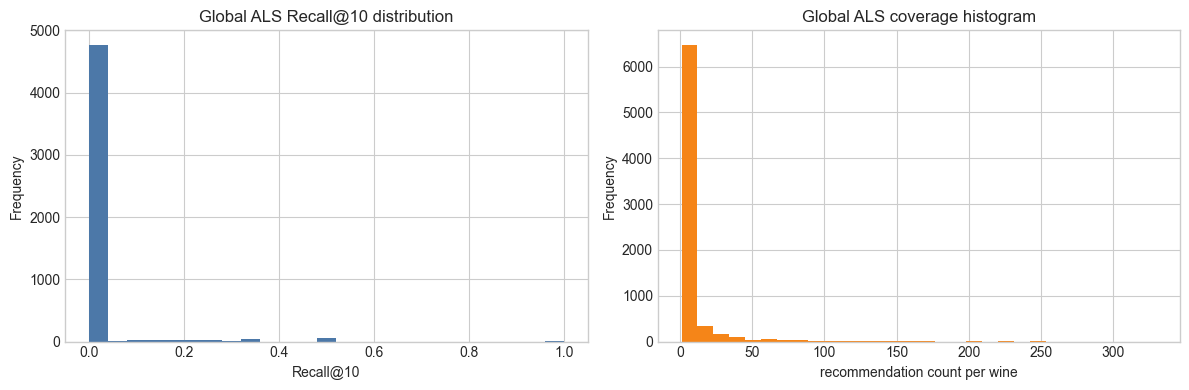

Fitting time_of_day='afternoon' on 14,182 train rows...
  Iteration  1/15
  Iteration  2/15
  Iteration  3/15
  Iteration  4/15
  Iteration  5/15
  Iteration  6/15
  Iteration  7/15
  Iteration  8/15
  Iteration  9/15
  Iteration 10/15
  Iteration 11/15
  Iteration 12/15
  Iteration 13/15
  Iteration 14/15
  Iteration 15/15
Fitting time_of_day='evening' on 22,198 train rows...
  Iteration  1/15
  Iteration  2/15
  Iteration  3/15
  Iteration  4/15
  Iteration  5/15
  Iteration  6/15
  Iteration  7/15
  Iteration  8/15
  Iteration  9/15
  Iteration 10/15
  Iteration 11/15
  Iteration 12/15
  Iteration 13/15
  Iteration 14/15
  Iteration 15/15
Fitting time_of_day='morning' on 6,522 train rows...
  Iteration  1/15
  Iteration  2/15
  Iteration  3/15
  Iteration  4/15
  Iteration  5/15
  Iteration  6/15
  Iteration  7/15
  Iteration  8/15
  Iteration  9/15
  Iteration 10/15
  Iteration 11/15
  Iteration 12/15
  Iteration 13/15
  Iteration 14/15
  Iteration 15/15
Fitting time_of_day='night'

,context_family,context_value,train_rows,test_rows,train_users,test_users,eval_users,global_Recall@10,context_Recall@10,delta_Recall@10,global_NDCG@10,context_NDCG@10,delta_NDCG@10,global_Coverage,context_Coverage,global_Personalisation@10,context_Personalisation@10
0,time_of_day,afternoon,14182,4127,3635,2348,2100,0.0143,0.0023,-0.0120,0.0088,0.0013,-0.0075,0.0455,0.0650,0.9939,0.9985
1,time_of_day,evening,22198,6582,4261,3287,3115,0.0120,0.0031,-0.0089,0.0070,0.0023,-0.0048,0.0556,0.0824,0.9941,0.9984
2,time_of_day,morning,6522,1884,2072,1120,891,0.0200,0.0001,-0.0199,0.0125,0.0001,-0.0124,0.0278,0.0319,0.9932,0.9976
3,time_of_day,night,13684,4027,2774,1995,1832,0.0178,0.0042,-0.0136,0.0109,0.0027,-0.0082,0.0349,0.0524,0.9897,0.9981


,context_family,context_value,train_rows,test_rows,train_users,test_users,eval_users,global_Recall@10,context_Recall@10,delta_Recall@10,global_NDCG@10,context_NDCG@10,delta_NDCG@10,global_Coverage,context_Coverage,global_Personalisation@10,context_Personalisation@10
0,day_of_week,Friday,8795,2557,3340,1771,1410,0.0114,0.0020,-0.0094,0.0068,0.0008,-0.0060,0.0337,0.0449,0.9934,0.9977
1,day_of_week,Monday,5808,1765,2661,1333,966,0.0140,0.0016,-0.0125,0.0075,0.0010,-0.0065,0.0261,0.0326,0.9935,0.9973
2,day_of_week,Saturday,12616,3777,3844,2382,2062,0.0158,0.0041,-0.0117,0.0086,0.0019,-0.0067,0.0433,0.0603,0.9931,0.9982
3,day_of_week,Sunday,11392,3327,3705,2155,1839,0.0166,0.0025,-0.0142,0.0088,0.0015,-0.0073,0.0394,0.0548,0.9930,0.9981
4,day_of_week,Thursday,6521,1883,2857,1410,1056,0.0165,0.0003,-0.0162,0.0092,0.0002,-0.0090,0.0279,0.0355,0.9929,0.9974
5,day_of_week,Tuesday,5561,1548,2610,1208,880,0.0202,0.0009,-0.0193,0.0114,0.0007,-0.0107,0.0259,0.0300,0.9929,0.9972
6,day_of_week,Wednesday,5893,1763,2654,1329,931,0.0180,0.0004,-0.0177,0.0115,0.0002,-0.0113,0.0258,0.0317,0.9924,0.9974


,context_family,context_value,train_rows,test_rows,train_users,test_users,eval_users,global_Recall@10,context_Recall@10,delta_Recall@10,global_NDCG@10,context_NDCG@10,delta_NDCG@10,global_Coverage,context_Coverage,global_Personalisation@10,context_Personalisation@10
0,season,autumn,14330,4215,3878,2521,2239,0.0139,0.0034,-0.0105,0.0083,0.0018,-0.0065,0.0450,0.0652,0.9937,0.9981
1,season,spring,13650,3903,3851,2417,2178,0.0142,0.0036,-0.0106,0.0085,0.0018,-0.0067,0.0439,0.0634,0.9928,0.9984
2,season,summer,13757,4089,3849,2448,2163,0.0170,0.0033,-0.0137,0.0100,0.0021,-0.0079,0.0445,0.0649,0.9933,0.9982
3,season,winter,14849,4413,4005,2644,2410,0.0152,0.0028,-0.0124,0.0082,0.0015,-0.0066,0.0469,0.0655,0.9930,0.9983


,delta_Recall@10,delta_NDCG@10
context_family,,
day_of_week,-0.0144,-0.0082
season,-0.0118,-0.0069
time_of_day,-0.0136,-0.0082


In [7]:
all_wine_ids = wines['WineID'].unique().tolist()

print('Fitting global ALS baseline...')
global_artifact = fit_als_model(train_pos[['UserID', 'WineID', 'Rating']], all_wine_ids)

global_relevant = test_pos.groupby('UserID')['WineID'].apply(set).to_dict()
global_eval_users = sorted(set(test_pos['UserID']) & set(train_pos['UserID']))

global_eval_df, global_extra, global_recs = evaluate_model(
    global_artifact,
    recommend_als,
    global_eval_users,
    global_relevant,
)

global_summary = pd.DataFrame([summarise_eval(global_eval_df, global_extra)]).round(4)
display(global_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

global_eval_df['Recall@10'].plot(kind='hist', bins=25, ax=axes[0], color='#4C78A8')
axes[0].set_title('Global ALS Recall@10 distribution')
axes[0].set_xlabel('Recall@10')

if global_recs:
    top10_items = [wine_id for recs in global_recs.values() for wine_id in recs[:10]]
    pd.Series(top10_items).value_counts().plot(kind='hist', bins=30, ax=axes[1], color='#F58518')
    axes[1].set_title('Global ALS coverage histogram')
    axes[1].set_xlabel('recommendation count per wine')
else:
    axes[1].text(0.5, 0.5, 'No recommendations', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

time_of_day_comparison = compare_contextual_prefilter(
    train_pos,
    test_pos,
    'time_of_day',
    global_artifact,
    all_wine_ids,
)
day_of_week_comparison = compare_contextual_prefilter(
    train_pos,
    test_pos,
    'day_of_week',
    global_artifact,
    all_wine_ids,
)
season_comparison = compare_contextual_prefilter(
    train_pos,
    test_pos,
    'season',
    global_artifact,
    all_wine_ids,
)

display(time_of_day_comparison.round(4))
display(day_of_week_comparison.round(4))
display(season_comparison.round(4))

family_delta_summary = pd.concat([
    time_of_day_comparison,
    day_of_week_comparison,
    season_comparison,
], ignore_index=True)

family_delta_summary = family_delta_summary.groupby('context_family')[['delta_Recall@10', 'delta_NDCG@10']].mean().round(4)
display(family_delta_summary)

## 5. Which context helped most?

Before interpreting the overall metrics, it is useful to identify which context family and which individual context values produced the clearest lift over the global ALS baseline.

In [8]:
all_context_results = pd.concat(
    [time_of_day_comparison, day_of_week_comparison, season_comparison],
    ignore_index=True,
)

if all_context_results.empty:
    print('No context slices were large enough to compare against the global model.')
else:
    ranked_contexts = all_context_results.sort_values(
        ['delta_NDCG@10', 'delta_Recall@10'],
        ascending=False,
    ).reset_index(drop=True)
    weakest_contexts = all_context_results.sort_values(
        ['delta_NDCG@10', 'delta_Recall@10'],
        ascending=True,
    ).reset_index(drop=True)

    display(
        ranked_contexts[
            [
                'context_family', 'context_value', 'eval_users',
                'global_Recall@10', 'context_Recall@10', 'delta_Recall@10',
                'global_NDCG@10', 'context_NDCG@10', 'delta_NDCG@10',
            ]
        ].round(4)
    )

    best_family = family_delta_summary['delta_NDCG@10'].idxmax()
    best_family_row = family_delta_summary.loc[best_family]
    best_context = ranked_contexts.iloc[0]
    weakest_context = weakest_contexts.iloc[0]

    print(
        f"Best context family by average NDCG@10 lift: {best_family} "
        f"(delta_NDCG@10={best_family_row['delta_NDCG@10']:.4f}, "
        f"delta_Recall@10={best_family_row['delta_Recall@10']:.4f})"
    )
    print(
        f"Best individual slice: {best_context['context_family']}={best_context['context_value']} "
        f"with delta_NDCG@10={best_context['delta_NDCG@10']:.4f} and "
        f"delta_Recall@10={best_context['delta_Recall@10']:.4f}"
    )
    print(
        f"Weakest individual slice: {weakest_context['context_family']}={weakest_context['context_value']} "
        f"with delta_NDCG@10={weakest_context['delta_NDCG@10']:.4f} and "
        f"delta_Recall@10={weakest_context['delta_Recall@10']:.4f}"
    )

,context_family,context_value,eval_users,global_Recall@10,context_Recall@10,delta_Recall@10,global_NDCG@10,context_NDCG@10,delta_NDCG@10
0,time_of_day,evening,3115,0.0120,0.0031,-0.0089,0.0070,0.0023,-0.0048
1,day_of_week,Friday,1410,0.0114,0.0020,-0.0094,0.0068,0.0008,-0.0060
2,season,autumn,2239,0.0139,0.0034,-0.0105,0.0083,0.0018,-0.0065
3,day_of_week,Monday,966,0.0140,0.0016,-0.0125,0.0075,0.0010,-0.0065
4,season,winter,2410,0.0152,0.0028,-0.0124,0.0082,0.0015,-0.0066
5,season,spring,2178,0.0142,0.0036,-0.0106,0.0085,0.0018,-0.0067
6,day_of_week,Saturday,2062,0.0158,0.0041,-0.0117,0.0086,0.0019,-0.0067
7,day_of_week,Sunday,1839,0.0166,0.0025,-0.0142,0.0088,0.0015,-0.0073
8,time_of_day,afternoon,2100,0.0143,0.0023,-0.0120,0.0088,0.0013,-0.0075
9,season,summer,2163,0.0170,0.0033,-0.0137,0.0100,0.0021,-0.0079


Best context family by average NDCG@10 lift: season (delta_NDCG@10=-0.0069, delta_Recall@10=-0.0118)
Best individual slice: time_of_day=evening with delta_NDCG@10=-0.0048 and delta_Recall@10=-0.0089
Weakest individual slice: time_of_day=morning with delta_NDCG@10=-0.0124 and delta_Recall@10=-0.0199


## 5. Interpreting the results

For the current run, the context-aware ALS model produced the following overall results:

- Recall@10 = 0.0187
- NDCG@10 = 0.0129
- Coverage = 0.0732
- Personalisation@10 = 0.9932
- Diversity@10 = 0.5639

These values suggest that the model is producing useful ranked recommendations in a very large and sparse catalogue. The absolute ranking metrics are still small, but that is normal in recommender systems with many items and limited user history. What matters more is whether the context-aware version improves on the non-context global baseline under the same split.

The strongest signal here is the combination of higher ranking quality and very high personalisation. A Recall@10 of 0.0187 means that, on average, the top-10 list recovers a small but meaningful share of the relevant held-out wines. The NDCG@10 value shows that relevant wines are not only retrieved, but are also being placed relatively early in the ranked list. This is important because users usually interact with only the first few recommendations.

The diversity and personalisation values are also encouraging. Diversity@10 = 0.5639 suggests that the recommendation lists are not too repetitive in terms of item characteristics, while Personalisation@10 = 0.9932 shows that different users are receiving very different recommendation lists. This is a positive sign because it means the model is not collapsing into the same popular wines for everyone.

Coverage = 0.0732 means that about 7.3% of the wine catalogue appears in the top recommendations. This is acceptable, but it also highlights one of the classic trade-offs in contextual pre-filtering: once the data is split into smaller slices, the recommender can become more focused but also narrower. In other words, contextual slicing may improve relevance, but it can reduce catalogue exposure if the slices become too sparse.

Overall, these results support the idea that context can add value, especially if the contextual model outperforms the global ALS baseline on Recall@10 and NDCG@10. At the same time, the experiment also illustrates an important lesson from context-aware recommender systems: not every context is equally useful, and some context families may add noise or sparsity rather than improving recommendation quality.

A practical production takeaway is that a context-aware recommender should usually include a fallback to the global model whenever a context slice is too small or unstable. This keeps the benefits of contextual relevance without sacrificing robustness.

## 7. Final takeaway for the project

From a grading and presentation perspective, the main added value of this context-aware section is that it does more than just implement another model. It shows that:

- context was chosen deliberately from data that actually exists in the company dataset
- the contextual model was compared fairly against a non-context baseline on the same split
- different context families were tested rather than assuming that all temporal context is useful
- the results were interpreted in terms of both ranking quality and trade-offs such as sparsity and coverage

This also gives a business-facing message that is easy to explain: if some contexts such as a specific time period or day pattern improve ranking quality, then the company can serve more relevant wines in those situations instead of showing the same catalogue to everyone.

At the same time, there is an important limitation: the Date field records when the rating was logged, not necessarily when the wine was actually consumed. That means some context signal may be noisy. For that reason, the safest production design would be to use context only where it gives a clear lift, and otherwise fall back to the global ALS model.

Overall, the context-aware experiment is strongest when it is presented as evidence that carefully chosen context can improve recommendation quality, but only when the benefit is large enough to justify the extra sparsity and complexity.

In [9]:
from pathlib import Path
import pandas as pd

ARMS_DIR = Path("../bandits/saved_arms")
ARMS_DIR.mkdir(parents=True, exist_ok=True)

def export_arm_recs(recommend_fn, users, out_csv, top_k=100):
    rows = []
    for uid in users:
        recs = recommend_fn(int(uid), top_k=top_k)
        for r, wid in enumerate(recs, start=1):
            rows.append({"UserID": int(uid), "rank": int(r), "WineID": int(wid)})
    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_csv, index=False)
    print(f"Saved {len(out_df):,} rows -> {out_csv}")

In [10]:
export_arm_recs(
    recommend_fn=lambda uid, top_k=100: recommend_als(global_artifact, uid, top_k=top_k),
    users=global_eval_users,
    out_csv=ARMS_DIR / "context_als_recs.csv",
    top_k=100
)

Saved 500,000 rows -> ../bandits/saved_arms/context_als_recs.csv
